### Дообучение ResNet18
- Цель: На основе ResNet18 получить модель, которая лучше чем Baseline

In [1]:
import os
import math
import time
import random
import json
from typing import Dict, List

import torch
import torchvision
from torch.utils.data import DataLoader, Subset
import torch.nn as nn

from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from torchmetrics.classification import MulticlassRecall, MulticlassF1Score, MulticlassPrecision, MulticlassAccuracy

from sklearn.model_selection import train_test_split

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = "../data/trashnet"
ARTIFACTS_DIR ="../artifacts"
LOG_FILE = "runs.csv"
NUM_CLASSES = 6
BATCH_SIZE = 128
EPOCHS_HEAD = 4
EPOCHS_FT   = 8
# -----------------------
# Воспроизводимость
# -----------------------
RANDOM_STATE = 42
def set_seed(seed: int = RANDOM_STATE) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)


# -----------------------
# Устройство
# -----------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print('torch:', torch.__version__)
print("torchvision:", torchvision.__version__)

Device: cpu
torch: 2.12.0+cpu
torchvision: 0.27.0+cpu


In [2]:
#v2.AutoAugmentPolicy.IMAGENET

IMGNET_IMG_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
tf_train = transforms.Compose([
    transforms.Resize(IMGNET_IMG_SIZE+32),
    transforms.CenterCrop(IMGNET_IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.4,             # Probability of applying the transform
        scale=(0.02, 0.20),# Range of proportion of erased area against the input image
        ratio=(0.3, 3.3),  # Range of aspect ratio of erased area
        value=0,           # Value to fill erased pixels (0 for black, or a tuple for RGB)
        inplace=False
    ),
    transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD),
])
tf_test = transforms.Compose([
    transforms.Resize(IMGNET_IMG_SIZE+32),
    transforms.CenterCrop(IMGNET_IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
])

train_full = ImageFolder(DATA_DIR,transform=tf_train)
test_full = ImageFolder(DATA_DIR,transform=tf_test)

targets = np.array(train_full.targets)

train_idx, temp_idx = train_test_split(
    range(len(train_full.targets)),
    test_size=0.2,
    stratify=targets,
    random_state=RANDOM_STATE,
    shuffle=True
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,              
    stratify=targets[temp_idx], 
    random_state=RANDOM_STATE,
    shuffle=True
)

train_dataset = Subset(train_full, train_idx)
val_dataset   = Subset(test_full, val_idx)
test_dataset  = Subset(test_full, test_idx)


In [3]:
# Создаем загрузчики данных

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available(),
                           generator=torch.Generator().manual_seed(RANDOM_STATE))
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print("="*20, "SANITY CHECK","="*20)

print("Данные по train")
batch = next(iter(train_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)


print("\nДанные по test")
batch = next(iter(train_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

==================== SANITY CHECK ====================
Данные по train
x: torch.Size([128, 3, 224, 224]) torch.float32
y: torch.Size([128]) torch.int64

Данные по test
x: torch.Size([128, 3, 224, 224]) torch.float32
y: torch.Size([128]) torch.int64


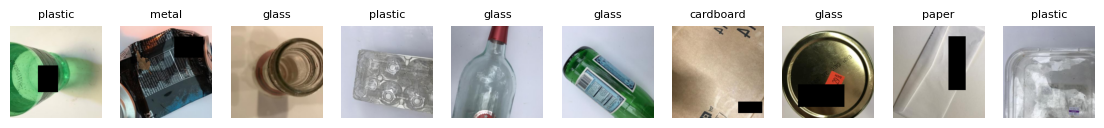

In [4]:
class_names = train_full.classes

def denorm_STL(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_STL(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [5]:
def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)


weights: ResNet18_Weights.IMAGENET1K_V1


In [6]:

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag


In [7]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


@torch.no_grad()
def metrics_on_loader(model, loader):

    model.eval()
    model.to(DEVICE)


    recall = MulticlassRecall(num_classes=NUM_CLASSES,average="macro").to(DEVICE)
    f1score = MulticlassF1Score(num_classes=NUM_CLASSES,average="macro").to(DEVICE)
    precision = MulticlassPrecision(num_classes=NUM_CLASSES,average="macro").to(DEVICE)
    accuracy = MulticlassAccuracy(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

    for x, labels in loader:
        x, labels = x.to(DEVICE), labels.to(DEVICE)
        logits = model(x)
        preds = torch.argmax(logits, dim=1)
        recall.update(preds,labels)
        f1score.update(preds,labels)
        precision.update(preds,labels)
        accuracy.update(preds,labels)

    metrics = {
        'accuracy': accuracy.compute().item(),
        'recall_macro': recall.compute().item(),
        'precision_macro': precision.compute().item(),
        'f1_macro': f1score.compute().item(),
    }
    
    return metrics


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        dt = time.time() - t0

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )


        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        
        

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]],save="", title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    if save:
        plt.tight_layout()
        plt.savefig(ARTIFACTS_DIR+"/figures/"+save+"_1.png")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    if save:
        plt.tight_layout()
        plt.savefig(ARTIFACTS_DIR+"/figures/"+save+"_2.png")
    plt.show()

Trainable params: 3078

Phase 1: head-only training
Epoch 01/4 | train loss 1.6341, acc 0.330 | val loss 1.3101, acc 0.530 | 40.7s
Epoch 02/4 | train loss 1.2135, acc 0.589 | val loss 1.0451, acc 0.644 | 38.8s
Epoch 03/4 | train loss 1.0018, acc 0.668 | val loss 0.9306, acc 0.676 | 38.6s
Epoch 04/4 | train loss 0.8848, acc 0.726 | val loss 0.8392, acc 0.704 | 41.6s
Лучшая acc на val: 0.7035573122529645


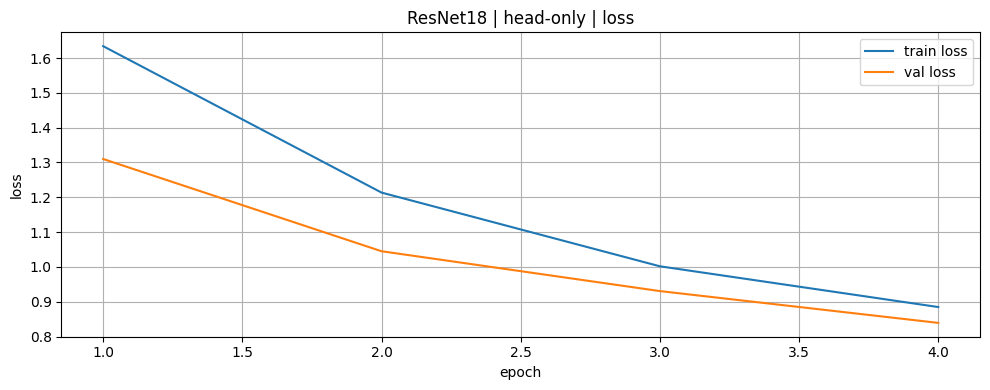

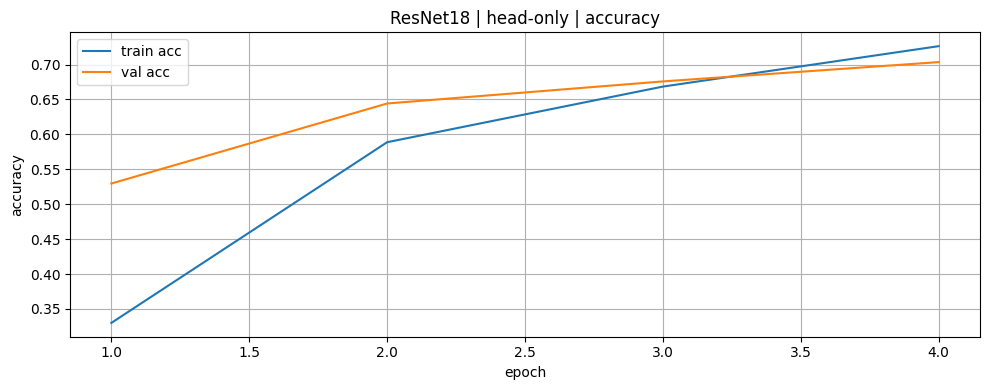

In [8]:
set_seed()
criterion = nn.CrossEntropyLoss()

resnet18_head_only = build_resnet18(num_classes=6, weights=weights).to(DEVICE)

# freeze всё
set_requires_grad(resnet18_head_only, False)
# размораживаем только голову
set_requires_grad(resnet18_head_only.fc, True)

print("Trainable params:", count_params(resnet18_head_only))

optimizer_head_only = torch.optim.Adam(resnet18_head_only.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = fit(resnet18_head_only, train_loader, val_loader, optimizer_head_only, criterion, epochs=EPOCHS_HEAD, verbose=True)
best_val_acc = float(np.nanmax(hist_head["val_acc"])) if len(hist_head["val_acc"]) else float("nan")
print(f"Лучшая acc на val: {best_val_acc}")
plot_history(hist_head, title="ResNet18 | head-only", save="ResNet_Head-Only_train")


In [ ]:
# Сохраняем результаты

Head_Only_data = {'experiment_id': 'R1',
           'task': 'classification',
           'dataset': 'TrashNet',
           'seed': RANDOM_STATE,
           'model_summary': f'Resnet18-head-only; Trainable params: {count_params(resnet18_head_only)}',
            'optimizer': 'Adam',
            'lr': 1e-3,
            'epochs_trained': EPOCHS_HEAD,
            'best_val_accuracy': best_val_acc,
            'test_accuracy': None,
            'precision': None,
            'recall': None,
            'notes':'very stong model', 
        }        
file_exists = os.path.exists(ARTIFACTS_DIR+"/"+LOG_FILE) and os.path.getsize(ARTIFACTS_DIR+"/"+LOG_FILE) > 0
pd.DataFrame([Head_Only_data]).to_csv(
            ARTIFACTS_DIR+"/"+LOG_FILE, 
            header=not file_exists, 
            mode='a', 
            index=False
        )

Trainable params (layer4+fc): 8396806

Phase 2: fine-tuning layer4 + fc
Epoch 01/8 | train loss 0.6399, acc 0.778 | val loss 0.4909, acc 0.830 | 47.6s
Epoch 02/8 | train loss 0.3126, acc 0.900 | val loss 0.3749, acc 0.858 | 50.0s
Epoch 03/8 | train loss 0.1866, acc 0.950 | val loss 0.3218, acc 0.897 | 54.6s
Epoch 04/8 | train loss 0.1181, acc 0.969 | val loss 0.2955, acc 0.893 | 50.7s
Epoch 05/8 | train loss 0.0790, acc 0.982 | val loss 0.2862, acc 0.897 | 49.6s
Epoch 06/8 | train loss 0.0571, acc 0.989 | val loss 0.2971, acc 0.905 | 48.5s
Epoch 07/8 | train loss 0.0462, acc 0.991 | val loss 0.2563, acc 0.937 | 50.3s
Epoch 08/8 | train loss 0.0331, acc 0.995 | val loss 0.2728, acc 0.909 | 49.8s
Лучшая acc на val: 0.9367588932806324


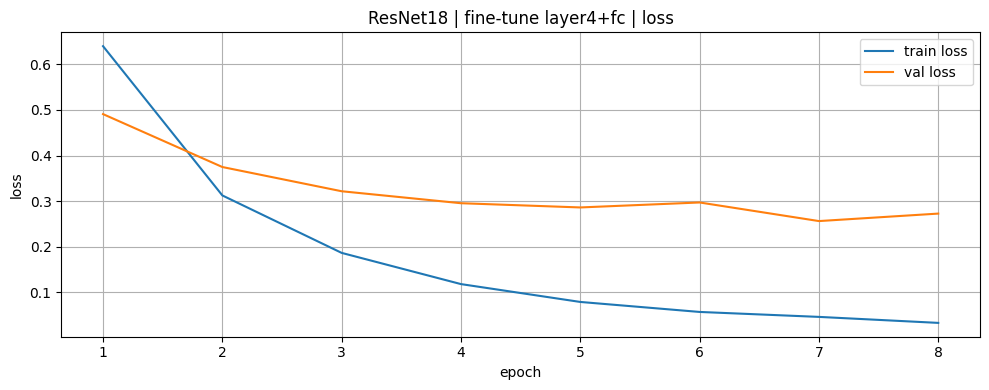

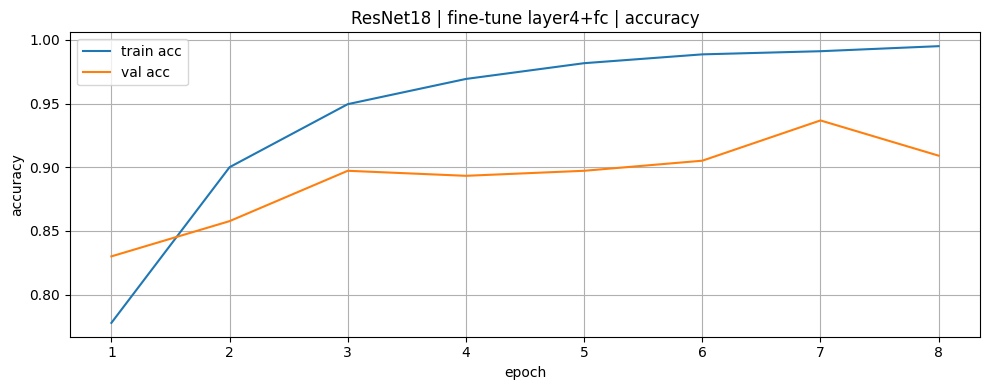

In [10]:
# Fine-tunning ResNet18

set_seed()
criterion = nn.CrossEntropyLoss()

# размораживаем layer4 и fc
set_requires_grad(resnet18_head_only.layer4, True)
set_requires_grad(resnet18_head_only.fc, True)

print("Trainable params (layer4+fc):", count_params(resnet18_head_only))

# param groups: backbone меньше, head больше
params = [
    {"params": resnet18_head_only.layer4.parameters(), "lr": 1e-4},
    {"params": resnet18_head_only.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = fit(resnet18_head_only, train_loader, val_loader, optimizer_ft, criterion, epochs=EPOCHS_FT, verbose=True)
best_val_acc = float(np.nanmax(hist_ft["val_acc"])) if len(hist_ft["val_acc"]) else float("nan")
print(f"Лучшая acc на val: {best_val_acc}")
plot_history(hist_ft, title="ResNet18 | fine-tune layer4+fc",save="ResNet_Fine-tunning")



In [11]:
print("Метрики на тест")
metrics = metrics_on_loader(resnet18_head_only,test_loader)
print(metrics)

Fine_Tunning_data = {'experiment_id': 'R2',
           'task': 'classification',
           'dataset': 'TrashNet',
           'seed': RANDOM_STATE,
           'model_summary': f'ResNet18-finetune; Trainable params: {count_params(resnet18_head_only)}',
            'optimizer': 'Adam',
            'lr': 1e-3,
            'epochs_trained': EPOCHS_FT,
            'best_val_accuracy': best_val_acc,
            'test_accuracy': metrics["accuracy"],
            'precision': metrics["precision_macro"],
            'recall': metrics["recall_macro"],
            'notes':'The best model', 
        }      
file_exists = os.path.exists(ARTIFACTS_DIR+"/"+LOG_FILE) and os.path.getsize(ARTIFACTS_DIR+"/"+LOG_FILE) > 0
pd.DataFrame([Fine_Tunning_data]).to_csv(
            ARTIFACTS_DIR+"/"+LOG_FILE, 
            header=not file_exists, 
            mode='a', 
            index=False
        )
torch.save(resnet18_head_only.state_dict(), ARTIFACTS_DIR+"/best_classifier.pt")

Метрики на тест
{'accuracy': 0.9110903143882751, 'recall_macro': 0.9110903143882751, 'precision_macro': 0.9235457181930542, 'f1_macro': 0.9165238738059998}


In [12]:
# Сохранение конфига лучшей модели
best_config = {
           'task': 'classification',
           'dataset': 'TrashNet',
           'transforms': [f"transforms.Resize({IMGNET_IMG_SIZE + 32})",
                             f"transforms.CenterCrop({IMGNET_IMG_SIZE})",
                             "transforms.RandomHorizontalFlip(p=0.5)",
                             "transforms.ToTensor()",
                             "transforms.RandomErasing(p=0.4, scale=(0.02, 0.20), ratio=(0.3, 3.3), value=0,inplace=False)",
                             f"transforms.Normalize({IMAGENET_MEAN}, {IMAGENET_STD})"],
           'seed': RANDOM_STATE,
           'model_summary': f'ResNet18-finetune; Trainable params: {count_params(resnet18_head_only)}',
            'optimizer': 'Adam',
            'criterion': "CrossEntropyLoss",
            'lr_head': 1e-3,
            'lr_backbone': 1e-4,
            'epochs_trained': EPOCHS_FT,  
            'path': ARTIFACTS_DIR+"/best_classifier.pt"
        } 
with open('../configs/best_classifier_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_config, f, ensure_ascii=False, indent=4)
print("Saved:", "../configs/best_classifier_config.json")

Saved: ../configs/best_classifier_config.json
